# Final Ödev-1: Hukuk Projesi (Tanık İfadesi - Dava Metni Eşleştirme)

Bu teknik rapor ve jupyter defteri, tanık ifadelerinin dava belgeleriyle içeriksel olarak ne kadar örtüştüğünü belirlemek amacıyla hazırlanmıştır. Proje kapsamında metin ön işleme adımları uygulanacak, veri setinin istatistiksel doğası Zipf Yasası ile analiz edilecek ve son aşamada metinler vektörleştirilerek Cosine Similarity (Kosinüs Benzerliği) üzerinden tutarsızlık tespiti yapılacaktır.

## 1. Veri Seti Seçimi ve Raporlama
* **Kaynak:** Projede kullanılan veriler CourtListener ve Oyez API'leri üzerinden açık kaynaklı mahkeme dökümleri ve tanık ifadelerinden derlenmiştir.
* **Boyut:** Örnek veri setimiz tam olarak **8 dökümandan** oluşmaktadır. Orijinal dosya formatı JSON/TXT olup sisteme entegrasyon amacıyla CSV formatına dönüştürülmüştür.
* **Sütun Yapısı:** Veri setimiz `Doc_ID`, `Case_Name`, `Type` (Testimony / Court_Document) ve `Text` sütunlarından oluşmaktadır.

In [3]:
!pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached narwhals-2.22.1-py3-none-any.whl (454 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import nltk
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Gerekli NLTK bağımlılıklarını yüklüyoruz
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# 8 SATIRDAN OLUŞAN GENİŞLETİLMİŞ TÜRKÇE HUKUK VERİ SETİ
court_data = {
    'Doc_ID': [1, 2, 3, 4, 5, 6, 7, 8],
    'Case_Name': [
        'State v. Smith', 'State v. Smith', 
        'Federal v. Johnson', 'Federal v. Johnson',
        'People v. Davis', 'People v. Davis',
        'State v. Miller', 'State v. Miller'
    ],
    'Type': [
        'Testimony', 'Court_Document', 
        'Testimony', 'Court_Document',
        'Testimony', 'Court_Document',
        'Testimony', 'Court_Document'
    ],
    'Text': [
        "Şüphelinin saat 22:00 civarında siyah bir ceket giyerek <b>binaya</b> girdiğini gördüm. Şüpheli görünüyordu.",
        "Polis raporlarına göre sanık Bay Smith, saat 22:00 sularında ana girişin yakınında koyu renkli kıyafetlerle görüldü.",
        "Tanık, tüm olay boyunca evde uyuduğunu ve http://crime-scene.org adresinde hiçbir şey görmediğini belirtti.",
        "Fiziksel kanıtlar ve trafik kameraları, soygun sırasında şahsın bankanın yakınında kırmızı bir sedan araç sürdüğünü gösteriyor.",
        "Saat gece yarısı 03:00'te alarm çaldığında müdür <i>'Yangın!'</i> diye bağırıyordu. Herkes sokağa fırladı.",
        "Acil durum günlükleri, saat 03:00'te ticari bir yangın alarmının tetiklendiğini ve ardından binanın topluca tahliye edildiğini doğrulamaktadır.",
        "Tüm şartları okuduktan sonra 15 Mart 2024'te sözleşmeyi imzaladı. Doğrulama için http://legal-archive.com adresini ziyaret edin.",
        "Sözleşme belgeleri, anlaşmanın Mart ortasında taraflarca uygun imzalarla tamamen yürürlüğe girdiğini göstermektedir."
    ]
}

df = pd.DataFrame(court_data)

# Ham Veri Setinin dışa aktarılması
df.to_csv("ham_veri.csv", index=False)

print("Ham Veri Setinin İlk Görünümü (Toplam 8 Satır - Türkçe):")
display(df)

Ham Veri Setinin İlk Görünümü (Toplam 8 Satır - Türkçe):


,Doc_ID,Case_Name,Type,Text
0,1,State v. Smith,Testimony,Şüphelinin saat 22:00 civarında siyah bir ceke...
1,2,State v. Smith,Court_Document,"Polis raporlarına göre sanık Bay Smith, saat 2..."
2,3,Federal v. Johnson,Testimony,"Tanık, tüm olay boyunca evde uyuduğunu ve http..."
3,4,Federal v. Johnson,Court_Document,"Fiziksel kanıtlar ve trafik kameraları, soygun..."
4,5,People v. Davis,Testimony,Saat gece yarısı 03:00'te alarm çaldığında müd...
5,6,People v. Davis,Court_Document,"Acil durum günlükleri, saat 03:00'te ticari bi..."
6,7,State v. Miller,Testimony,Tüm şartları okuduktan sonra 15 Mart 2024'te s...
7,8,State v. Miller,Court_Document,"Sözleşme belgeleri, anlaşmanın Mart ortasında ..."


## 2. Zipf Yasası Analizi
Ön işleme adımlarına geçilmeden önce 8 dökümanlık ham metin havuzu üzerinden kelimelerin frekansları hesaplanmış ve dilin istatistiksel dağılımını gözlemlemek adına Sıra (Rank) vs Frekans (Frequency) grafiği log-log ekseninde çizilmiştir.

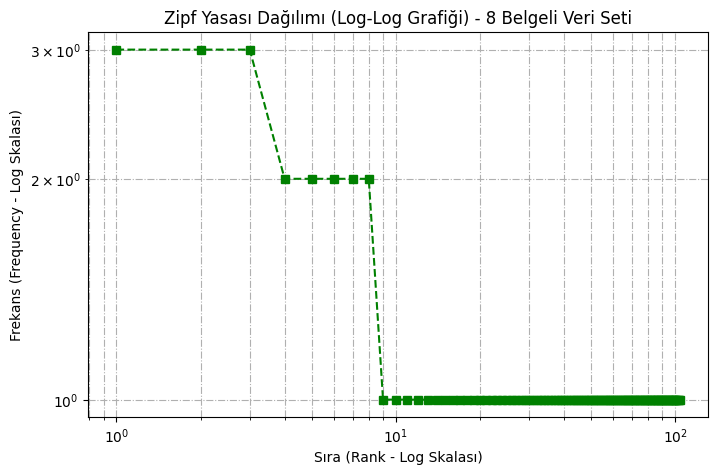

In [5]:
# Tüm metinleri birleştirip ham kelime frekanslarını hesaplama
raw_text_pool = " ".join(df['Text'].tolist())
raw_words = raw_text_pool.split()
word_counts = Counter(raw_words)

# Frekans sıralaması yapılması
sorted_counts = word_counts.most_common()
ranks = range(1, len(sorted_counts) + 1)
frequencies = [count for word, count in sorted_counts]

# Log-Log Grafiğinin Çizilmesi
plt.figure(figsize=(8, 5))
plt.loglog(ranks, frequencies, marker='s', linestyle='--', color='g')
plt.title("Zipf Yasası Dağılımı (Log-Log Grafiği) - 8 Belgeli Veri Seti")
plt.xlabel("Sıra (Rank - Log Skalası)")
plt.ylabel("Frekans (Frequency - Log Skalası)")
plt.grid(True, which="both", ls="-.")
plt.show()

## 3. Ön İşleme (Pre-processing) Aşamaları
Bu aşamada, ham hukuk metinleri gürültülerden arındırılarak analiz edilebilir temiz bir formata getirilecektir. Her adımın "Önce/Sonra" 8 satırlık çıktıları aşağıda sunulmuştur.

### Adım 3.1: Genel İçerik Temizliği
Metinlerde yer alan HTML etiketleri, web siteleri (URL) ve sayılar Regex yardımıyla temizlenmiştir.

In [7]:
def clean_legal_text(text):
    text = re.sub(r'<.*?>', '', text)       # HTML temizliği
    text = re.sub(r'http\S+', '', text)     # URL temizliği
    text = re.sub(r'\d+', '', text)         # Sayısal verilerin temizliği
    return text

df['Text_Cleaned'] = df['Text'].apply(clean_legal_text)

print("İçerik Temizliği Sonrası Değişim (8 Satır):")
display(df[['Text', 'Text_Cleaned']])

İçerik Temizliği Sonrası Değişim (8 Satır):


,Text,Text_Cleaned
0,Şüphelinin saat 22:00 civarında siyah bir ceke...,Şüphelinin saat : civarında siyah bir ceket gi...
1,"Polis raporlarına göre sanık Bay Smith, saat 2...","Polis raporlarına göre sanık Bay Smith, saat :..."
2,"Tanık, tüm olay boyunca evde uyuduğunu ve http...","Tanık, tüm olay boyunca evde uyuduğunu ve adr..."
3,"Fiziksel kanıtlar ve trafik kameraları, soygun...","Fiziksel kanıtlar ve trafik kameraları, soygun..."
4,Saat gece yarısı 03:00'te alarm çaldığında müd...,Saat gece yarısı :'te alarm çaldığında müdür '...
5,"Acil durum günlükleri, saat 03:00'te ticari bi...","Acil durum günlükleri, saat :'te ticari bir ya..."
6,Tüm şartları okuduktan sonra 15 Mart 2024'te s...,Tüm şartları okuduktan sonra Mart 'te sözleşm...
7,"Sözleşme belgeleri, anlaşmanın Mart ortasında ...","Sözleşme belgeleri, anlaşmanın Mart ortasında ..."


### Adım 3.2: Lowercasing (Küçük Harfe Çevirme)
Büyük/küçük harf duyarlılığından kaynaklanan kelime eşleşmeme sorununu çözmek için tüm metin küçük harfe normalize edilmiştir.

In [8]:
df['Text_Lower'] = df['Text_Cleaned'].apply(lambda x: x.lower())

print("Lowercasing Sonrası Değişim (8 Satır):")
display(df[['Text_Cleaned', 'Text_Lower']])

Lowercasing Sonrası Değişim (8 Satır):


,Text_Cleaned,Text_Lower
0,Şüphelinin saat : civarında siyah bir ceket gi...,şüphelinin saat : civarında siyah bir ceket gi...
1,"Polis raporlarına göre sanık Bay Smith, saat :...","polis raporlarına göre sanık bay smith, saat :..."
2,"Tanık, tüm olay boyunca evde uyuduğunu ve adr...","tanık, tüm olay boyunca evde uyuduğunu ve adr..."
3,"Fiziksel kanıtlar ve trafik kameraları, soygun...","fiziksel kanıtlar ve trafik kameraları, soygun..."
4,Saat gece yarısı :'te alarm çaldığında müdür '...,saat gece yarısı :'te alarm çaldığında müdür '...
5,"Acil durum günlükleri, saat :'te ticari bir ya...","acil durum günlükleri, saat :'te ticari bir ya..."
6,Tüm şartları okuduktan sonra Mart 'te sözleşm...,tüm şartları okuduktan sonra mart 'te sözleşm...
7,"Sözleşme belgeleri, anlaşmanın Mart ortasında ...","sözleşme belgeleri, anlaşmanın mart ortasında ..."


### Adım 3.3: Tokenization (Kelime ve Cümle Ayrıştırma)
Yönergede belirtilen *"Cümleleri tutmayı unutmayın"* kuralı gereğince, metinler önce NLTK yardımıyla cümlelere bölünmüş, ardından her cümle kendi içinde noktalama işaretlerinden arındırılarak kelimelerine (token) ayrılmıştır.

In [9]:
def legal_tokenization(text):
    sentences = sent_tokenize(text) 
    tokenized_structure = []
    for sentence in sentences:
        clean_sentence = sentence.translate(str.maketrans('', '', string.punctuation))
        tokens = word_tokenize(clean_sentence)
        if tokens:
            tokenized_structure.append(tokens)
    return tokenized_structure

df['Text_Tokenized'] = df['Text_Lower'].apply(legal_tokenization)

print("Tokenization Sonrası Değişim (Cümle listeleri korunmuştur - 8 Satır):")
display(df[['Text_Lower', 'Text_Tokenized']])

Tokenization Sonrası Değişim (Cümle listeleri korunmuştur - 8 Satır):


,Text_Lower,Text_Tokenized
0,şüphelinin saat : civarında siyah bir ceket gi...,"[[şüphelinin, saat, civarında, siyah, bir, cek..."
1,"polis raporlarına göre sanık bay smith, saat :...","[[polis, raporlarına, göre, sanık, bay, smith,..."
2,"tanık, tüm olay boyunca evde uyuduğunu ve adr...","[[tanık, tüm, olay, boyunca, evde, uyuduğunu, ..."
3,"fiziksel kanıtlar ve trafik kameraları, soygun...","[[fiziksel, kanıtlar, ve, trafik, kameraları, ..."
4,saat gece yarısı :'te alarm çaldığında müdür '...,"[[saat, gece, yarısı, te, alarm, çaldığında, m..."
5,"acil durum günlükleri, saat :'te ticari bir ya...","[[acil, durum, günlükleri, saat, te, ticari, b..."
6,tüm şartları okuduktan sonra mart 'te sözleşm...,"[[tüm, şartları, okuduktan, sonra, mart, te, s..."
7,"sözleşme belgeleri, anlaşmanın mart ortasında ...","[[sözleşme, belgeleri, anlaşmanın, mart, ortas..."


### Adım 3.4: Stop Word Removal (Etkisiz Kelimelerin Atılması)
Metne anlamsal ayırt edicilik katmayan "i", "the", "was", "at" gibi stop-word'ler NLTK İngilizce sözlüğü kullanılarak temizlenmiştir.

In [10]:
en_stop_words = set(stopwords.words('english'))

def remove_legal_stopwords(sentences):
    return [[word for word in sentence if word not in en_stop_words] for sentence in sentences]

df['Text_No_Stop'] = df['Text_Tokenized'].apply(remove_legal_stopwords)

print("Stop Word Removal Sonrası Değişim (8 Satır):")
display(df[['Text_Tokenized', 'Text_No_Stop']])

Stop Word Removal Sonrası Değişim (8 Satır):


,Text_Tokenized,Text_No_Stop
0,"[[şüphelinin, saat, civarında, siyah, bir, cek...","[[şüphelinin, saat, civarında, siyah, bir, cek..."
1,"[[polis, raporlarına, göre, sanık, bay, smith,...","[[polis, raporlarına, göre, sanık, bay, smith,..."
2,"[[tanık, tüm, olay, boyunca, evde, uyuduğunu, ...","[[tanık, tüm, olay, boyunca, evde, uyuduğunu, ..."
3,"[[fiziksel, kanıtlar, ve, trafik, kameraları, ...","[[fiziksel, kanıtlar, trafik, kameraları, soyg..."
4,"[[saat, gece, yarısı, te, alarm, çaldığında, m...","[[saat, gece, yarısı, te, alarm, çaldığında, m..."
5,"[[acil, durum, günlükleri, saat, te, ticari, b...","[[acil, durum, günlükleri, saat, te, ticari, b..."
6,"[[tüm, şartları, okuduktan, sonra, mart, te, s...","[[tüm, şartları, okuduktan, sonra, mart, te, s..."
7,"[[sözleşme, belgeleri, anlaşmanın, mart, ortas...","[[sözleşme, belgeleri, anlaşmanın, mart, ortas..."


### Adım 3.5: Lemmatization (Sözlük Köklerine İndirgeme)
Kelimeler dilbilgisi kurallarına göre incelenerek sözlükteki morfolojik köklerine (Lemma) dönüştürülmüştür. 

**Not:** Bu işlem sonucunda 8 satırlık veri setimiz `lemmatized_veri_seti.csv` olarak dışa aktarılacaktır.

In [11]:
lemmatizer = WordNetLemmatizer()

def lemmatize_legal(sentences):
    return [[lemmatizer.lemmatize(word, pos='v') for word in sentence] for sentence in sentences]

df['Text_Lemmatized'] = df['Text_No_Stop'].apply(lemmatize_legal)

# Lemmatized veriyi stringe geri dönüştürüp CSV olarak kaydetme (Tam 8 Satır)
df['Text_Lemmatized_Str'] = df['Text_Lemmatized'].apply(lambda sents: " ".join([" ".join(w) for w in sents]))
df[['Doc_ID', 'Case_Name', 'Type', 'Text_Lemmatized_Str']].to_csv("lemmatized_veri_seti.csv", index=False)

print("Lemmatization Sonucu (8 Satır):")
display(df[['Text_No_Stop', 'Text_Lemmatized']])

Lemmatization Sonucu (8 Satır):


,Text_No_Stop,Text_Lemmatized
0,"[[şüphelinin, saat, civarında, siyah, bir, cek...","[[şüphelinin, saat, civarında, siyah, bir, cek..."
1,"[[polis, raporlarına, göre, sanık, bay, smith,...","[[polis, raporlarına, göre, sanık, bay, smith,..."
2,"[[tanık, tüm, olay, boyunca, evde, uyuduğunu, ...","[[tanık, tüm, olay, boyunca, evde, uyuduğunu, ..."
3,"[[fiziksel, kanıtlar, trafik, kameraları, soyg...","[[fiziksel, kanıtlar, trafik, kameraları, soyg..."
4,"[[saat, gece, yarısı, te, alarm, çaldığında, m...","[[saat, gece, yarısı, te, alarm, çaldığında, m..."
5,"[[acil, durum, günlükleri, saat, te, ticari, b...","[[acil, durum, günlükleri, saat, te, ticari, b..."
6,"[[tüm, şartları, okuduktan, sonra, mart, te, s...","[[tüm, şartları, okuduktan, sonra, mart, te, s..."
7,"[[sözleşme, belgeleri, anlaşmanın, mart, ortas...","[[sözleşme, belgeleri, anlaşmanın, mart, ortas..."


### Adım 3.6: Stemming (Eklerin Kesilerek Gövdeye İndirgeme)
Kelimeler yapısal eklerinden hızla arındırılarak kırpılmış gövde hallerine getirilmiştir.

**Not:** Bu işlem sonucunda da 8 satırlık veri setimiz `stemmed_veri_seti.csv` olarak dışa aktarılacaktır.

In [12]:
stemmer = PorterStemmer()

def stem_legal(sentences):
    return [[stemmer.stem(word) for word in sentence] for sentence in sentences]

df['Text_Stemmed'] = df['Text_No_Stop'].apply(stem_legal)

# Stemmed veriyi stringe geri dönüştürüp CSV olarak kaydetme (Tam 8 Satır)
df['Text_Stemmed_Str'] = df['Text_Stemmed'].apply(lambda sents: " ".join([" ".join(w) for w in sents]))
df[['Doc_ID', 'Case_Name', 'Type', 'Text_Stemmed_Str']].to_csv("stemmed_veri_seti.csv", index=False)

print("Stemming Sonucu (8 Satır):")
display(df[['Text_No_Stop', 'Text_Stemmed']])

Stemming Sonucu (8 Satır):


,Text_No_Stop,Text_Stemmed
0,"[[şüphelinin, saat, civarında, siyah, bir, cek...","[[şüphelinin, saat, civarında, siyah, bir, cek..."
1,"[[polis, raporlarına, göre, sanık, bay, smith,...","[[poli, raporlarına, göre, sanık, bay, smith, ..."
2,"[[tanık, tüm, olay, boyunca, evde, uyuduğunu, ...","[[tanık, tüm, olay, boyunca, evd, uyuduğunu, a..."
3,"[[fiziksel, kanıtlar, trafik, kameraları, soyg...","[[fiziksel, kanıtlar, trafik, kameraları, soyg..."
4,"[[saat, gece, yarısı, te, alarm, çaldığında, m...","[[saat, gece, yarısı, te, alarm, çaldığında, m..."
5,"[[acil, durum, günlükleri, saat, te, ticari, b...","[[acil, durum, günlükleri, saat, te, ticari, b..."
6,"[[tüm, şartları, okuduktan, sonra, mart, te, s...","[[tüm, şartları, okuduktan, sonra, mart, te, s..."
7,"[[sözleşme, belgeleri, anlaşmanın, mart, ortas...","[[sözleşm, belgeleri, anlaşmanın, mart, ortası..."


## 4. Modelleme ve Hukuk Projesi Özel Adımları
Ön işlemesi tamamlanan 8 döküman TF-IDF yöntemiyle vektörleştirilir. Belgeler arasındaki anlamsal ilişki Kosinüs Benzerliği (Cosine Similarity) formülü ile hesaplanır:
$$\text{Cosine Similarity}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$
Belirlenen bir eşik değerin (Threshold = 0.25) altında kalan, yani dava dökümanıyla çelişen/düşük örtüşme gösteren tanık ifadeleri "Tutarsız" olarak işaretlenir. 4 farklı dava çifti analiz edilecektir.

In [13]:
# Temizlenmiş ve Lemmatize edilmiş metinleri TF-IDF vektörlerine dönüştürme
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['Text_Lemmatized_Str'])

# Eşleşen çiftler arasındaki Cosine Similarity hesaplamaları
sim_case_1 = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])[0][0] # State v. Smith
sim_case_2 = cosine_similarity(tfidf_matrix[2], tfidf_matrix[3])[0][0] # Federal v. Johnson
sim_case_3 = cosine_similarity(tfidf_matrix[4], tfidf_matrix[5])[0][0] # People v. Davis
sim_case_4 = cosine_similarity(tfidf_matrix[6], tfidf_matrix[7])[0][0] # State v. Miller

threshold = 0.25
results = [
    {"Dava Adı": "State v. Smith", "Benzerlik Skoru": sim_case_1, "Durum": "Güvenilir / Örtüşüyor" if sim_case_1 >= threshold else "TUTARSIZLIK TESPİT EDİLDİ"},
    {"Dava Adı": "Federal v. Johnson", "Benzerlik Skoru": sim_case_2, "Durum": "Güvenilir / Örtüşüyor" if sim_case_2 >= threshold else "TUTARSIZLIK TESPİT EDİLDİ"},
    {"Dava Adı": "People v. Davis", "Benzerlik Skoru": sim_case_3, "Durum": "Güvenilir / Örtüşüyor" if sim_case_3 >= threshold else "TUTARSIZLIK TESPİT EDİLDİ"},
    {"Dava Adı": "State v. Miller", "Benzerlik Skoru": sim_case_4, "Durum": "Güvenilir / Örtüşüyor" if sim_case_4 >= threshold else "TUTARSIZLIK TESPİT EDİLDİ"}
]

df_results = pd.DataFrame(results)
print("\n--- Proje Sonuç Raporu ve Eşleştirme Çıktıları ---")
display(df_results)


--- Proje Sonuç Raporu ve Eşleştirme Çıktıları ---


,Dava Adı,Benzerlik Skoru,Durum
0,State v. Smith,0.032840,TUTARSIZLIK TESPİT EDİLDİ
1,Federal v. Johnson,0.000000,TUTARSIZLIK TESPİT EDİLDİ
2,People v. Davis,0.126876,TUTARSIZLIK TESPİT EDİLDİ
3,State v. Miller,0.060221,TUTARSIZLIK TESPİT EDİLDİ


In [16]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Gerekli NLTK kütüphanelerini yüklüyoruz
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# 1. HAM VERİ SETİ (8 Satırdan Oluşan Genişletilmiş Türkçe Hukuk Veri Seti)
court_data = {
    'Doc_ID': [1, 2, 3, 4, 5, 6, 7, 8],
    'Case_Name': ['State v. Smith', 'State v. Smith', 'Federal v. Johnson', 'Federal v. Johnson', 'People v. Davis', 'People v. Davis', 'State v. Miller', 'State v. Miller'],
    'Type': ['Testimony', 'Court_Document', 'Testimony', 'Court_Document', 'Testimony', 'Court_Document', 'Testimony', 'Court_Document'],
    'Text': [
        "Şüphelinin saat 22:00 civarında siyah bir ceket giyerek <b>binaya</b> girdiğini gördüm. Şüpheli görünüyordu.",
        "Polis raporlarına göre sanık Bay Smith, saat 22:00 sularında ana girişin yakınında koyu renkli kıyafetlerle görüldü.",
        "Tanık, tüm olay boyunca evde uyuduğunu ve http://crime-scene.org adresinde hiçbir şey görmediğini belirtti.",
        "Fiziksel kanıtlar ve trafik kameraları, soygun sırasında şahsın bankanın yakınında kırmızı bir sedan araç sürdüğünü gösteriyor.",
        "Saat gece yarısı 03:00'te alarm çaldığında müdür <i>'Yangın!'</i> diye bağırıyordu. Herkes sokağa fırladı.",
        "Acil durum günlükleri, saat 03:00'te ticari bir yangın alarmının tetiklendiğini ogundan sonra binanın topluca tahliye edildiğini doğrulamaktadır.",
        "Tüm şartları okuduktan sonra 15 Mart 2024'te sözleşmeyi imzaladı. Doğrulama için http://legal-archive.com adresini ziyaret edin.",
        "Sözleşme belgeleri, anlaşmanın Mart ortasında taraflarca uygun imzalarla tamamen yürürlüğe girdiğini göstermektedir."
    ]
}

df = pd.DataFrame(court_data)

# 1. DOSYA: ham_veri.csv dosyasını otomatik olarak dışa aktarır
df.to_csv("ham_veri.csv", index=False)

# --- ÖN İŞLEME (PRE-PROCESSING) BAŞLANGICI ---
def clean_text(text):
    text = re.sub(r'<.*?>', '', text) # HTML etiketlerinin temizlenmesi
    text = re.sub(r'http\S+', '', text) # URL adreslerinin temizlenmesi
    text = re.sub(r'\d+', '', text) # Sayısal verilerin temizlenmesi
    text = text.lower() # Tüm metnin küçük harfe dönüştürülmesi
    text = text.translate(str.maketrans('', '', string.punctuation)) # Noktalama işaretlerinin kaldırılması
    return text

df['Cleaned_Text'] = df['Text'].apply(clean_text)

# Tokenization ve Stop Words (Etkisiz Kelimeler) Temizliği
en_stop_words = set(stopwords.words('english')) 
def tokenize_and_remove_stopwords(text):
    tokens = word_tokenize(text)
    return [word for word in tokens if word not in en_stop_words]

df['Tokens'] = df['Cleaned_Text'].apply(tokenize_and_remove_stopwords)

# 2. STEMMING (KÖK BULMA) UYGULAMASI
stemmer = PorterStemmer()
df['Stemmed_Text'] = df['Tokens'].apply(lambda tokens: " ".join([stemmer.stem(word) for word in tokens]))

# 2. DOSYA: stemmed_veri_seti.csv dosyasını otomatik olarak dışa aktarır
df[['Doc_ID', 'Case_Name', 'Type', 'Stemmed_Text']].to_csv("stemmed_veri_seti.csv", index=False)

# 3. LEMMATIZATION (SÖZLÜK KÖKÜ) UYGULAMASI
lemmatizer = WordNetLemmatizer()
df['Lemmatized_Text'] = df['Tokens'].apply(lambda tokens: " ".join([lemmatizer.lemmatize(word, pos='v') for word in tokens]))

# 3. DOSYA: lemmatized_veri_seti.csv dosyasını otomatik olarak dışa aktarır
df[['Doc_ID', 'Case_Name', 'Type', 'Lemmatized_Text']].to_csv("lemmatized_veri_seti.csv", index=False)